# Framework
1. Analyse Lyrics - Bert based, Hatebert, senwave bert
2. Analyse beat - Tempo, rhythm, chord, key, structure, spectral, loudness, visualizations
3. Participant section - 

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize
from collections import Counter
from nltk.util import ngrams
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from transformers import BertForSequenceClassification, BertTokenizer
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
from nltk.corpus import stopwords
stopwords = set(stopwords.words('english'))

c:\Users\jiyon\Desktop\Programming_projects\UNSW\musictransformationanalysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
nltk.download('punkt')
nltk.download('stopwords')
# set sns plot 
sns.set_theme()
sns.set_theme(style="whitegrid")
sns.set_context("talk")
barcolors = ['#87B88C','#9ED2A1','#E7E8CB','#48A0C9','#2A58A1','#2E8B55','#DF3659','Grey']
barstyle = {"edgecolor":"black", "linewidth":1}

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jiyon\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jiyon\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Lyric Analysis - Kanye

In [3]:
df = pd.DataFrame(columns=["song_title", "song_lyrics"])

In [4]:
def censor_words(tokens):  # renamed 'text' to 'tokens' to be clearer
    word_censor = {
        "nigga": "n*gga",
        "nigger": "n*gger",
        "anal": "@n@l",
        "booty": "b**ty",
        "pussy": "p*ssy",
        "sex": "s*x",
        "niggas": "n*ggas"
    }
    return [word_censor.get(word, word) for word in tokens]

def clean_lyrics(text, include_labels=False):
    if include_labels:
        text = re.sub(r"(?<!\[)[\"'(),{}\]?](?!])", "", text)
    else:
        text = re.sub(r"\[.*?\]", "", text)
        text = re.sub(r"[\"'(),\[\]{}?]", "", text)

    text = text.lower()
    tokens = word_tokenize(text)
    tokens = censor_words(tokens)  # Assuming you defined this elsewhere
    tokens = [token for token in tokens if token not in stopwords]
    return tokens

In [5]:
def create_ngram_df(lyrics, artist):
    ngram_df = pd.DataFrame(columns=["ngram", "freq", "ngram_type"])
    bigram = Counter(list(ngrams(lyrics, 2)))
    trigram = Counter(list(ngrams(lyrics, 3)))
    for bi, freq in bigram.items():
        ngram_df = pd.concat([pd.DataFrame([[bi, freq, "bigram"]], columns=ngram_df.columns), ngram_df], ignore_index=True)
    for tri, freq in trigram.items():
        ngram_df = pd.concat([pd.DataFrame([[tri, freq, "trigram"]], columns=ngram_df.columns), ngram_df], ignore_index=True)
    ngram_df['artist'] =  artist
    return ngram_df

In [6]:
def get_top_ngrams(df):
    top_10_bigrams = df[df['ngram_type'] == "bigram"].sort_values("freq", ascending=False).head(10)
    top_10_trigrams = df[df['ngram_type'] == "trigram"].sort_values("freq", ascending=False).head(10)
    return top_10_bigrams, top_10_trigrams

# Lyric Analysis - Cardi B

In [42]:
def read_lyrics(artists, new=False):
    lyrics = {}
    for i, artist in enumerate(artists, start=1):
        path = f"../song{i}/lyrics_new.txt" if new else f"../song{i}/lyrics.txt" 
        with open(path, "r", encoding="utf-8") as f:
            contents = f.read()
        lyrics[artist] = contents
    return lyrics



def create_df(artists=["Kanye West", "Cardi B", "Elton John", "Tom Macdonald"], new=False):
    res = pd.DataFrame(columns=["ngram", "freq", "ngram_type", "artist"])
    artist_lyrics = read_lyrics(artists, new)
    for artist, lyric in artist_lyrics.items():
        ngram_df = create_ngram_df(clean_lyrics(lyric), artist)
        res = pd.concat([res, ngram_df], ignore_index=True)
        
    return res


In [10]:
ngram_df = create_df() # concatenate the songs into one df

In [11]:
ngram_df

,ngram,freq,ngram_type,artist
0,"(hands, n*gga, heil)",1,trigram,Kanye West
1,"(world, hands, n*gga)",1,trigram,Kanye West
2,"(got, world, hands)",1,trigram,Kanye West
3,"(pants, got, world)",1,trigram,Kanye West
4,"(reachin, pants, got)",1,trigram,Kanye West
...,...,...,...,...
1828,"(understand, reasons)",1,bigram,Tom Macdonald
1829,"(didnt, understand)",1,bigram,Tom Macdonald
1830,"(shit, didnt)",1,bigram,Tom Macdonald
1831,"(guilty, shit)",1,bigram,Tom Macdonald


In [12]:
ngram_df['rank'] = ngram_df.groupby(['ngram_type', 'artist'])['freq'].rank(method="first", ascending=False)
top_ngrams = ngram_df[ngram_df['rank'] <= 10].drop(columns="rank")

In [13]:
top_ngrams


,ngram,freq,ngram_type,artist
16,"(nazis, n*gga, heil)",3,trigram,Kanye West
17,"(n*ggas, nazis, n*gga)",3,trigram,Kanye West
18,"(hitler, n*ggas, nazis)",3,trigram,Kanye West
19,"(heil, hitler, n*ggas)",3,trigram,Kanye West
20,"(hey, n*gga, heil)",3,trigram,Kanye West
...,...,...,...,...
1736,"(boy, wish)",4,bigram,Tom Macdonald
1737,"(bad, white)",4,bigram,Tom Macdonald
1738,"(oh, bad)",4,bigram,Tom Macdonald
1740,"(say, white)",7,bigram,Tom Macdonald


In [46]:
import matplotlib.patheffects as path_effects
import numpy as np
artists = ["Kanye West", "Cardi B", "Elton John", "Tom Macdonald"]

def make_artist_ngram_plot(top_ngrams):
    
    # Enhanced color palette with more vibrant colors
    artist_colors = {
        "Kanye West": ['#3498db', '#e74c3c'],       # Bright blue & red
        "Cardi B":    ['#2ecc71', '#f39c12'],       # Emerald green & orange
        "Elton John": ['#9b59b6', '#e91e63'],       # Purple & pink
        "Tom Macdonald": ['#f1c40f', '#1abc9c'],    # Yellow & teal
    }
    
    # Define bar style with enhanced effects
    barstyle = {
        'edgecolor': 'black',
        'linewidth': 1,
        'alpha': 0.9,
    }
    
    plt.rcParams.update({
        'font.size': 16,
        'axes.labelcolor': '#333333',
        'axes.titlepad': 20
    })
    
    fig, axes = plt.subplots(len(artists), 2, figsize=(14, 6 * len(artists)), 
                           constrained_layout=True, facecolor='#f8f9fa')
    
    for i, artist in enumerate(artists):
        bigram = top_ngrams[
            (top_ngrams['artist'] == artist) & 
            (top_ngrams['ngram_type'] == 'bigram')
        ]
        trigram = top_ngrams[
            (top_ngrams['artist'] == artist) & 
            (top_ngrams['ngram_type'] == 'trigram')
        ]
        
        # Plot bigram with enhanced styling
        bigram_sorted = bigram.sort_values('freq', ascending=True)
        ax_bigram = axes[i, 0]
        bigram_sorted.plot.barh(
            x='ngram',
            y='freq',
            ax=ax_bigram,
            color=artist_colors[artist][0],
            legend=False,
            **barstyle
        )
        

        ax_bigram.set_xlabel("Count", fontsize=20, fontweight='bold')
        ax_bigram.invert_xaxis()
        ax_bigram.grid(True, axis='x', linestyle='--', alpha=0.4, color='gray')
        ax_bigram.tick_params(axis='y', labelsize=20)
        ax_bigram.tick_params(axis='x', labelsize=18)
        ax_bigram.set_title(f"{artist}", fontsize=22, fontweight='bold',
                          path_effects=[path_effects.withStroke(linewidth=2, foreground='white')])
        ax_bigram.set_facecolor('#f8f9fa')
        
        # Plot trigram with enhanced styling
        trigram_sorted = trigram.sort_values('freq', ascending=True)
        ax_trigram = axes[i, 1]
        trigram_sorted.plot.barh(
            x='ngram',
            y='freq',
            ax=ax_trigram,
            color=artist_colors[artist][1],
            legend=False,
            **barstyle
        )
        
        
        ax_trigram.set_xlabel("Count", fontsize=20, fontweight='bold')
        ax_trigram.yaxis.set_tick_params(left=False, labelleft=False, right=True, labelright=True)
        ax_trigram.set_ylabel("")
        ax_trigram.grid(True, axis='x', linestyle='--', alpha=0.4, color='gray')
        ax_trigram.tick_params(axis='y', labelsize=20)
        ax_trigram.tick_params(axis='x', labelsize=18)
        ax_trigram.set_title(f"{artist}", fontsize=22, fontweight='bold',
                           path_effects=[path_effects.withStroke(linewidth=2, foreground='white')])
        ax_trigram.set_facecolor('#f8f9fa')
    
    # Add overall title
    fig.suptitle('Most Frequent N-grams by Artist', 
                fontsize=24, fontweight='bold', y=1.02,
                path_effects=[path_effects.withStroke(linewidth=3, foreground='white')])
    
    plt.show()

In [15]:
top_ngrams

,ngram,freq,ngram_type,artist
16,"(nazis, n*gga, heil)",3,trigram,Kanye West
17,"(n*ggas, nazis, n*gga)",3,trigram,Kanye West
18,"(hitler, n*ggas, nazis)",3,trigram,Kanye West
19,"(heil, hitler, n*ggas)",3,trigram,Kanye West
20,"(hey, n*gga, heil)",3,trigram,Kanye West
...,...,...,...,...
1736,"(boy, wish)",4,bigram,Tom Macdonald
1737,"(bad, white)",4,bigram,Tom Macdonald
1738,"(oh, bad)",4,bigram,Tom Macdonald
1740,"(say, white)",7,bigram,Tom Macdonald


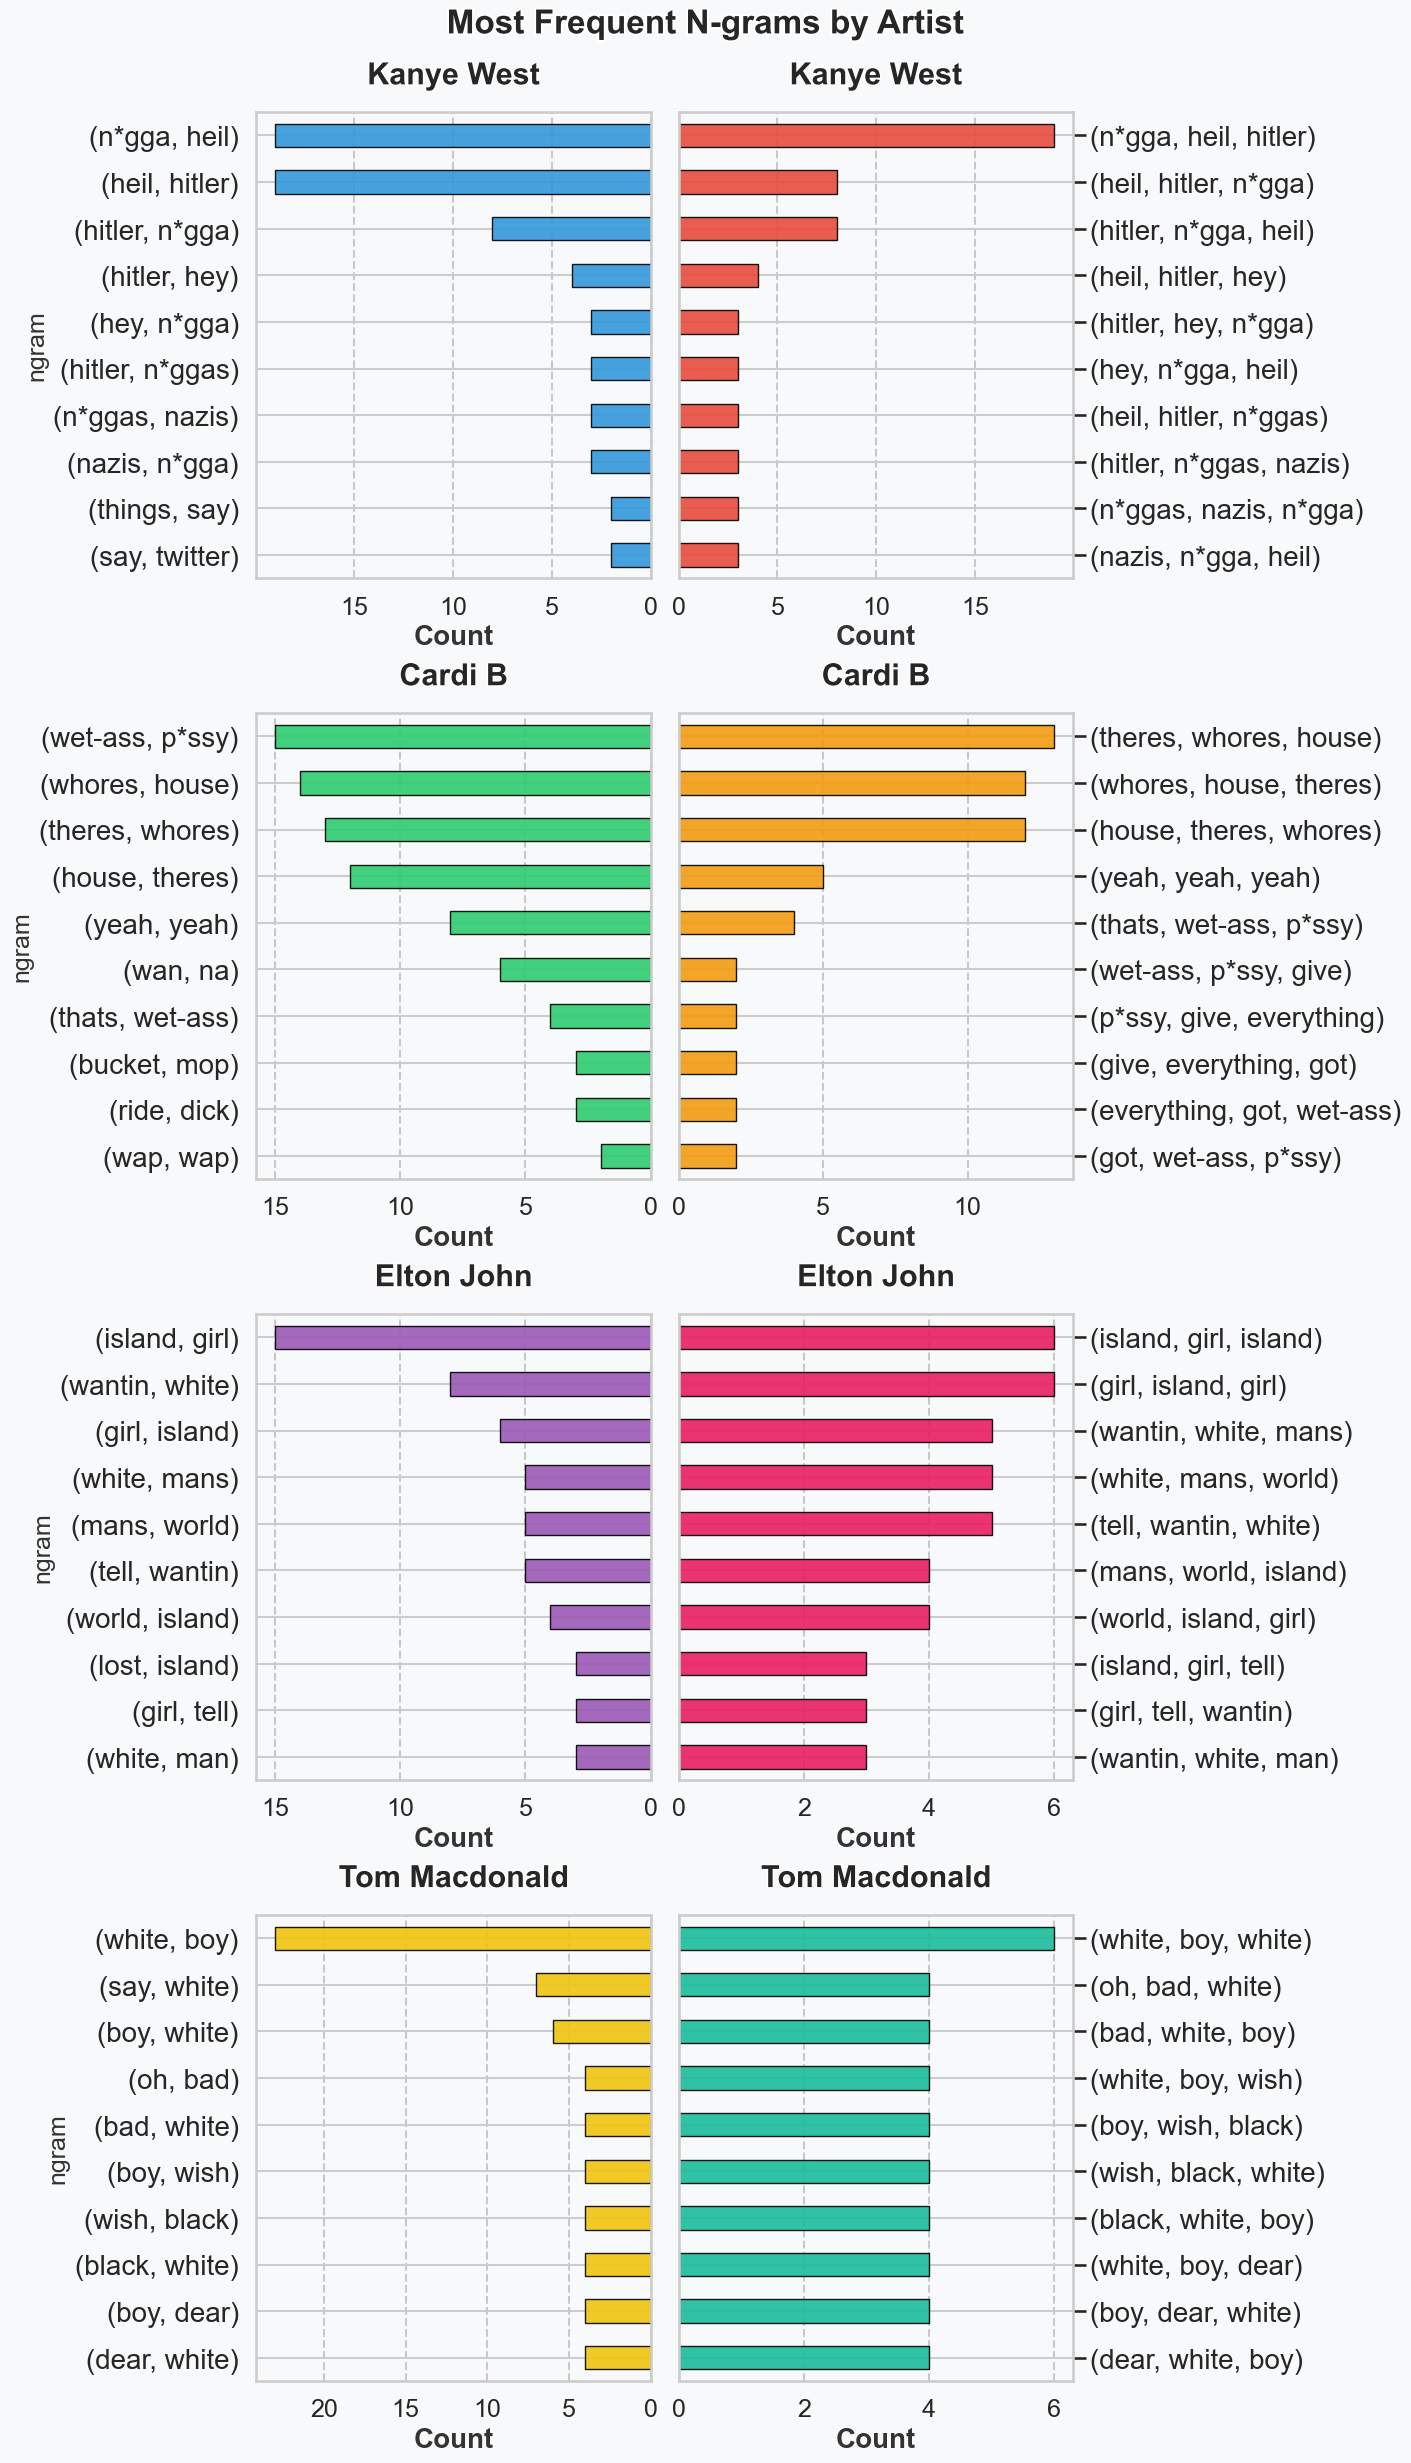

In [16]:
make_artist_ngram_plot(top_ngrams)


In [17]:
def preprocess_lines(lyrics):
    
    lines = lyrics.split("\n")
    lines = [x for x in lines if x != ""]
    return lines

In [18]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
tokenizer = AutoTokenizer.from_pretrained("Hate-speech-CNERG/bert-base-uncased-hatexplain")
model = AutoModelForSequenceClassification.from_pretrained("Hate-speech-CNERG/bert-base-uncased-hatexplain")

In [19]:
def predict_hate_speech(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    predicted_class = torch.argmax(logits, dim=1).item()
    
    return predicted_class




In [20]:
from transformers import pipeline
sentiment = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


In [21]:
df

,song_title,song_lyrics


In [ ]:
line_sentiment = pd.DataFrame(columns=["line", "sentiment", "section", "artist"])
artist_lyric = read_lyrics().items()

for artist, lyric in artist_lyric:
    current_section = None
    for line in preprocess_lines(lyric):
        if line.startswith("[") and line.endswith("]"):
            raw_section = line.strip("[]").strip()
            lower = raw_section.lower()

            # Use regex to match section types while preserving original labels
            if re.match(r"^verse(\b|:)", lower):
                current_section = "Verse"
            elif re.match(r"^(post-)?chorus(\b|:)", lower):
                current_section = "Chorus"
            elif re.match(r"^intro(\b|:)", lower):
                current_section = "Intro"  # Keep as Intro
            elif re.match(r"^outro(\b|:)", lower):
                current_section = "Outro"  # Keep as Outro
            elif re.match(r"^bridge(\b|:)", lower):
                current_section = "Bridge"  # Changed from Verse to Bridge
            else:
                current_section = None  # Unrecognized section, skip
            continue  # Skip the section label line itself

        if current_section is None:
            continue  # Skip lines not under a valid section

        s = 1 if sentiment(line)[0]['label'] == "NEGATIVE" else 0
        row = pd.DataFrame([[line, s, current_section, artist]], columns=line_sentiment.columns)
        line_sentiment = pd.concat([line_sentiment, row], ignore_index=True)

In [23]:
line_sentiment

,line,sentiment,section,artist
0,"Man, these people took my kids from me, then t...",1,Verse,Kanye West
1,"I got so much anger in me, got no way to take ...",1,Verse,Kanye West
2,"Think I'm stuck in The Matrix, where the fuck'...",1,Verse,Kanye West
3,"Yes, I am a cuck, I like when people fuck on m...",0,Verse,Kanye West
4,"The shit that I'm posting on Twitter, they tel...",1,Verse,Kanye West
...,...,...,...,...
235,Don't tell me how to see it through my white eyes,1,Chorus,Tom Macdonald
236,"White boy, don't say that",1,Chorus,Tom Macdonald
237,"White boy, oh, you so bad",1,Chorus,Tom Macdonald
238,"White boy, you wish you were black",1,Chorus,Tom Macdonald


In [24]:
line_sentiment['line_number'] = line_sentiment.groupby("artist").cumcount()+1

In [25]:
line_sentiment

,line,sentiment,section,artist,line_number
0,"Man, these people took my kids from me, then t...",1,Verse,Kanye West,1
1,"I got so much anger in me, got no way to take ...",1,Verse,Kanye West,2
2,"Think I'm stuck in The Matrix, where the fuck'...",1,Verse,Kanye West,3
3,"Yes, I am a cuck, I like when people fuck on m...",0,Verse,Kanye West,4
4,"The shit that I'm posting on Twitter, they tel...",1,Verse,Kanye West,5
...,...,...,...,...,...
235,Don't tell me how to see it through my white eyes,1,Chorus,Tom Macdonald,88
236,"White boy, don't say that",1,Chorus,Tom Macdonald,89
237,"White boy, oh, you so bad",1,Chorus,Tom Macdonald,90
238,"White boy, you wish you were black",1,Chorus,Tom Macdonald,91


In [27]:
line_sentiment.to_csv("../data/lines.csv")

In [28]:
df = line_sentiment.copy()
df["sentiment"] = pd.to_numeric(df["sentiment"], errors="coerce")
df = df.sort_values(["artist", "line_number"])
df["cum_lines"] = df.groupby("artist").cumcount() + 1
df["cumulative_neg"] = df.groupby("artist")["sentiment"].cumsum()
df["cumulative_neg_prop"] = df["cumulative_neg"] / df["cum_lines"]

In [29]:
def get_sentiment_score(text):
    return sentiment(text)

def get_and_standardize_sentiment(text):
    result = get_sentiment_score(text)[0]
    label = result['label']
    score = result['score']
    
    if label == 'POSITIVE':
        standardized = 0.5 - (score - 0.5)
    else: 
        standardized = 0.5 + (score - 0.5)
    
    standardized = max(0, min(1, standardized))
    return standardized

df['sentiment_score'] = df['line'].apply(get_and_standardize_sentiment)


In [30]:
df

,line,sentiment,section,artist,line_number,cum_lines,cumulative_neg,cumulative_neg_prop,sentiment_score
32,Whores in this house,1,Intro,Cardi B,1,1,1,1.000000,0.999138
33,There's some whores in this house,1,Intro,Cardi B,2,2,2,1.000000,0.997879
34,There's some whores in this house,1,Intro,Cardi B,3,3,3,1.000000,0.997879
35,There's some whores in this house (Hol' up),1,Intro,Cardi B,4,4,4,1.000000,0.997526
36,"I said certified freak, seven days a week",0,Intro,Cardi B,5,5,4,0.800000,0.311465
...,...,...,...,...,...,...,...,...,...
235,Don't tell me how to see it through my white eyes,1,Chorus,Tom Macdonald,88,88,60,0.681818,0.998307
236,"White boy, don't say that",1,Chorus,Tom Macdonald,89,89,61,0.685393,0.992553
237,"White boy, oh, you so bad",1,Chorus,Tom Macdonald,90,90,62,0.688889,0.999739
238,"White boy, you wish you were black",1,Chorus,Tom Macdonald,91,91,63,0.692308,0.993438


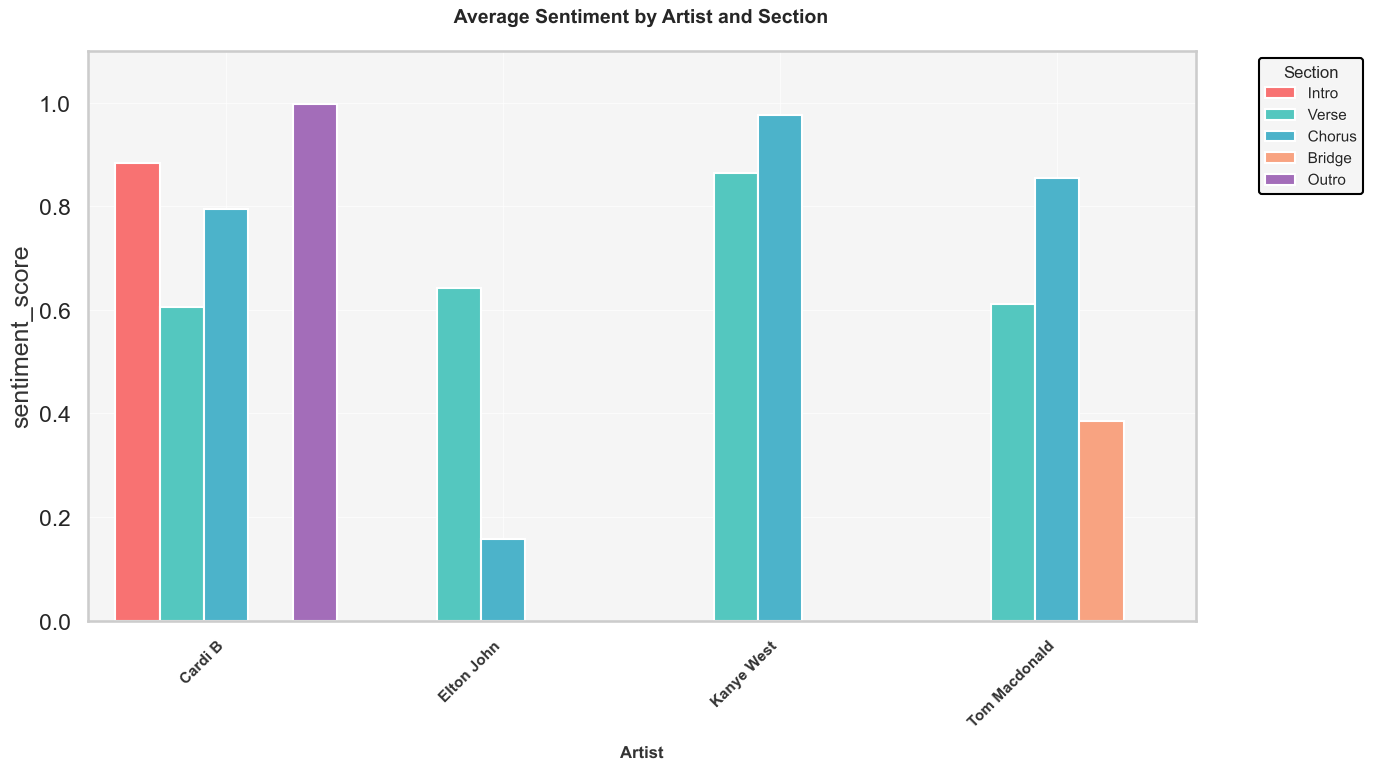

In [31]:
import matplotlib.patheffects as path_effects 
section_sentiment = df.groupby(['artist', 'section'])['sentiment_score'].mean().reset_index()

# Create a custom vibrant color palette for sections
section_colors = {
    'Intro': '#FF6B6B',    # Vibrant red
    'Verse': '#4ECDC4',    # Turquoise
    'Chorus': '#45B7D1',   # Bright blue 
    'Bridge': '#FFA07A',   # Light salmon
    'Outro': '#A569BD',    # Purple
    'Pre-Chorus': '#F4D03F',  # Yellow
    'Hook': '#58D68D'      # Green
}

plt.figure(figsize=(14, 8))

# Create the plot with custom colors
ax = sns.barplot(
    data=section_sentiment,
    x='artist',
    y='sentiment_score',
    hue='section',
    palette=section_colors,
    saturation=0.9,
    order=sorted(section_sentiment['artist'].unique()),
    hue_order=['Intro', 'Verse', 'Chorus', 'Bridge', 'Outro'],
    errorbar=None
)

# Customize the plot with vibrant style
plt.title('Average Sentiment by Artist and Section', pad=20, fontsize=14, fontweight='bold',
          path_effects=[path_effects.withStroke(linewidth=2, foreground='white')])
plt.xlabel('Artist', labelpad=12, fontsize=12, fontweight='bold',
          path_effects=[path_effects.withStroke(linewidth=2, foreground='white')])
plt.ylim(0, 1.1)



# Make the legend stand out
legend = plt.legend(
    title='Section',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    frameon=True,
    title_fontsize=12,
    fontsize=11,
    framealpha=1,
    edgecolor='black',
    facecolor='#f5f5f5'
)

# Apply text outline to legend
for text in legend.get_texts():
    text.set_path_effects([path_effects.withStroke(linewidth=1, foreground='white')])

# Style the plot background
ax.set_facecolor('#f5f5f5')
plt.grid(True, color='white', linestyle='-', linewidth=0.5)

# Rotate x-axis labels with style
plt.xticks(
    rotation=45, 
    ha='right',
    fontsize=11,
    fontweight='bold',
    color='#333333'
)

plt.tight_layout()
plt.show()

In [32]:
df

,line,sentiment,section,artist,line_number,cum_lines,cumulative_neg,cumulative_neg_prop,sentiment_score
32,Whores in this house,1,Intro,Cardi B,1,1,1,1.000000,0.999138
33,There's some whores in this house,1,Intro,Cardi B,2,2,2,1.000000,0.997879
34,There's some whores in this house,1,Intro,Cardi B,3,3,3,1.000000,0.997879
35,There's some whores in this house (Hol' up),1,Intro,Cardi B,4,4,4,1.000000,0.997526
36,"I said certified freak, seven days a week",0,Intro,Cardi B,5,5,4,0.800000,0.311465
...,...,...,...,...,...,...,...,...,...
235,Don't tell me how to see it through my white eyes,1,Chorus,Tom Macdonald,88,88,60,0.681818,0.998307
236,"White boy, don't say that",1,Chorus,Tom Macdonald,89,89,61,0.685393,0.992553
237,"White boy, oh, you so bad",1,Chorus,Tom Macdonald,90,90,62,0.688889,0.999739
238,"White boy, you wish you were black",1,Chorus,Tom Macdonald,91,91,63,0.692308,0.993438


In [33]:
df.groupby(["artist", "section"])['sentiment_score'].mean()

artist         section
Cardi B        Chorus     0.793685
               Intro      0.883896
               Outro      0.997879
               Verse      0.605400
Elton John     Chorus     0.156685
               Verse      0.641846
Kanye West     Chorus     0.975915
               Verse      0.863180
Tom Macdonald  Bridge     0.385303
               Chorus     0.854022
               Verse      0.610652
Name: sentiment_score, dtype: float64

In [34]:
df.groupby("artist")["sentiment"].mean()

artist
Cardi B          0.743902
Elton John       0.235294
Kanye West       0.937500
Tom Macdonald    0.684783
Name: sentiment, dtype: float64

<Figure size 1200x600 with 0 Axes>

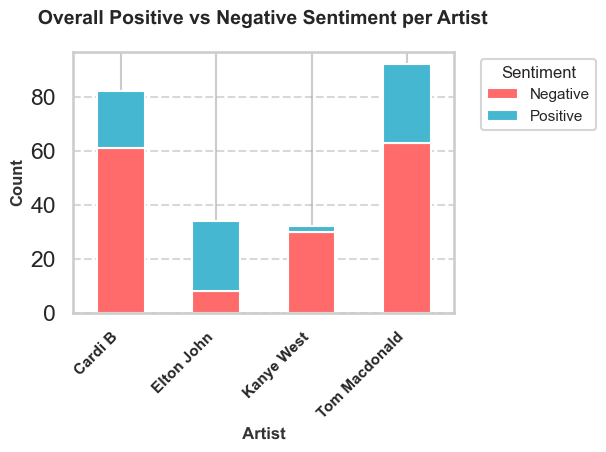

In [35]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects

# Classify sentiment as Positive or Negative
df['sentiment_class'] = df['sentiment'].apply(lambda x: 'Positive' if x == 0 else 'Negative')

artist_counts = df.groupby(['artist', 'sentiment_class']).size().unstack(fill_value=0)

plt.figure(figsize=(12,6))
ax = artist_counts.plot(kind='bar', stacked=True, color={'Positive':'#45B7D1','Negative':'#FF6B6B'})

# Title + labels
plt.title('Overall Positive vs Negative Sentiment per Artist', fontsize=14, fontweight='bold',
          path_effects=[path_effects.withStroke(linewidth=2, foreground='white')])
plt.xlabel('Artist', fontsize=12, fontweight='bold',
          path_effects=[path_effects.withStroke(linewidth=1.5, foreground='white')])
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11, fontweight='bold')
plt.grid(axis='y', color='gray', linestyle='--', alpha=0.3)

# Move legend outside
ax.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.show()


In [68]:
from sentence_transformers import SentenceTransformer, util


In [69]:
model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')


In [70]:
rows = []

for index, artist in enumerate(artists, start=1):
    root = f"song{index}_lyrics"
    original_path = f"../song{index}/lyrics.txt"
    transformed_path = f"../song{index}/lyrics_new.txt"

    # Function to process a file and detect sections
    def process_file(path, version):
        try:
            with open(path, "r", encoding="utf-8") as f:
                f = [i for i in f if not i.startswith("[") and i.strip() != ""] # remove section headers and make sure it's not empty
                for line_num, line in enumerate(f, start=1):
                    stripped = line.strip()
                    lower = stripped.lower()
                    # Append the line
                    rows.append({
                        "artist": artist,
                        "version": version,
                        "line_number": line_num,
                        "line": stripped
                    })
        except FileNotFoundError:
            print(f"Warning: {path} not found.")

    # Process original and transformed files
    process_file(original_path, "original")
    process_file(transformed_path, "transformed")

# Create DataFrame
combined = pd.DataFrame(rows)

In [71]:
combined

,artist,version,line_number,line
0,Kanye West,original,1,"Man, these people took my kids from me, then t..."
1,Kanye West,original,2,"I got so much anger in me, got no way to take ..."
2,Kanye West,original,3,"Think I'm stuck in The Matrix, where the fuck'..."
3,Kanye West,original,4,"Yes, I am a cuck, I like when people fuck on m..."
4,Kanye West,original,5,"The shit that I'm posting on Twitter, they tel..."
...,...,...,...,...
469,Tom Macdonald,transformed,82,Try to see the world through another’s eyes
470,Tom Macdonald,transformed,83,"Stand up, don’t say that"
471,Tom Macdonald,transformed,84,"Stand up, learn the facts"
472,Tom Macdonald,transformed,85,"Stand up, use your voice back"


In [75]:
df_pivot = combined.pivot_table(
    index=['artist', 'line_number'],
    columns='version',
    values='line',
    aggfunc='first'
).reset_index()
df_pivot = df_pivot.dropna(subset=['original', 'transformed'])

In [76]:
embeddings_orig = model.encode(df_pivot['original'].tolist(), convert_to_tensor=True)
embeddings_trans = model.encode(df_pivot['transformed'].tolist(), convert_to_tensor=True)

# Compute cosine similarity for each pair
cosine_scores = util.cos_sim(embeddings_orig, embeddings_trans)
similarities = [cosine_scores[i, i].item() for i in range(len(df_pivot))]

# Add similarity to DataFrame
df_pivot['semantic_similarity'] = similarities

print(df_pivot.head())

version   artist  line_number                                     original  \
0        Cardi B            1                         Whores in this house   
1        Cardi B            2            There's some whores in this house   
2        Cardi B            3            There's some whores in this house   
3        Cardi B            4  There's some whores in this house (Hol' up)   
4        Cardi B            5    I said certified freak, seven days a week   

version                                 transformed  semantic_similarity  
0                               Stars in this house             0.509442  
1                  There’s some stars in this house             0.544895  
2                  There’s some stars in this house             0.544895  
3        There’s some stars in this house (Hol’ up)             0.667506  
4         I said certified queen, seven days a week             0.774379  


In [77]:
df_pivot


version,artist,line_number,original,transformed,semantic_similarity
0,Cardi B,1,Whores in this house,Stars in this house,0.509442
1,Cardi B,2,There's some whores in this house,There’s some stars in this house,0.544895
2,Cardi B,3,There's some whores in this house,There’s some stars in this house,0.544895
3,Cardi B,4,There's some whores in this house (Hol' up),There’s some stars in this house (Hol’ up),0.667506
4,Cardi B,5,"I said certified freak, seven days a week","I said certified queen, seven days a week",0.774379
...,...,...,...,...,...
229,Tom Macdonald,82,"White boy, oh, you so bad",Try to see the world through another’s eyes,0.142173
230,Tom Macdonald,83,"White boy, you wish you were black","Stand up, don’t say that",0.223691
231,Tom Macdonald,84,"White boy, dear white boy","Stand up, learn the facts",0.202033
232,Tom Macdonald,85,"White boy, white noise","Stand up, use your voice back",0.184808


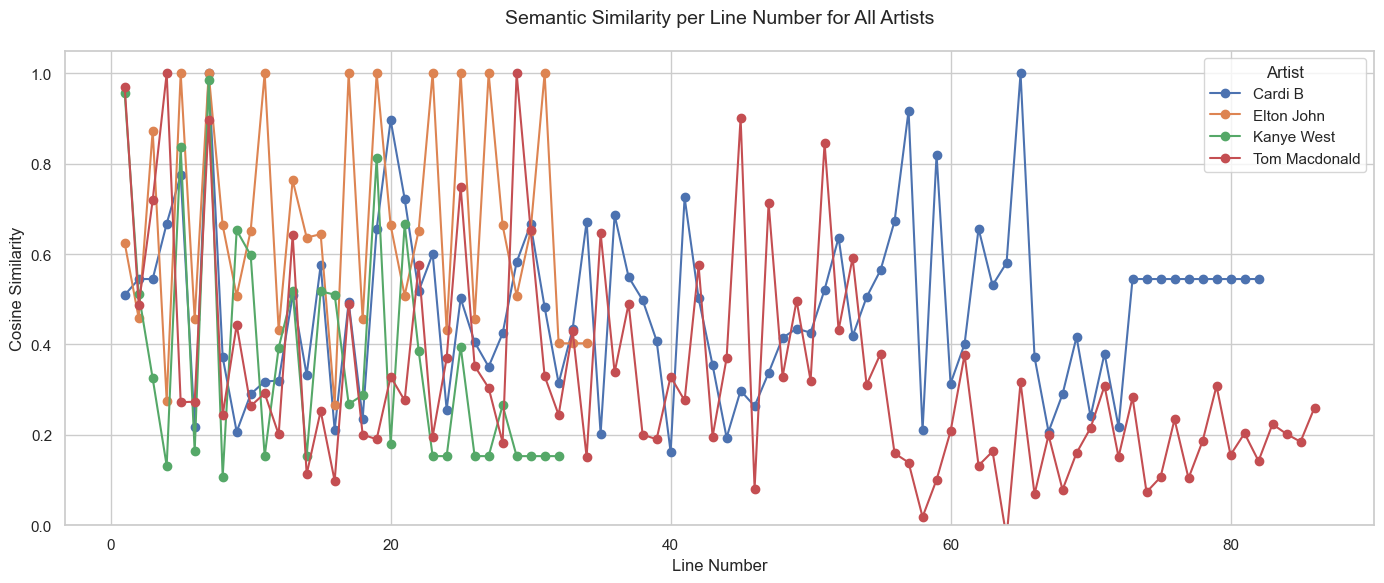

In [79]:
sns.set(style="whitegrid")

plt.figure(figsize=(14, 6))

# List of artists
artists = df_pivot['artist'].unique()

# Plot each artist on the same axes
for artist in artists:
    artist_df = df_pivot[df_pivot['artist'] == artist]
    plt.plot(
        artist_df['line_number'],
        artist_df['semantic_similarity'],
        marker='o',
        linestyle='-',
        label=artist
    )

plt.title("Semantic Similarity per Line Number for All Artists", fontsize=14)
plt.xlabel("Line Number")
plt.ylabel("Cosine Similarity")
plt.ylim(0, 1.05)
plt.legend(title="Artist")
plt.grid(True)
plt.tight_layout()
plt.show()

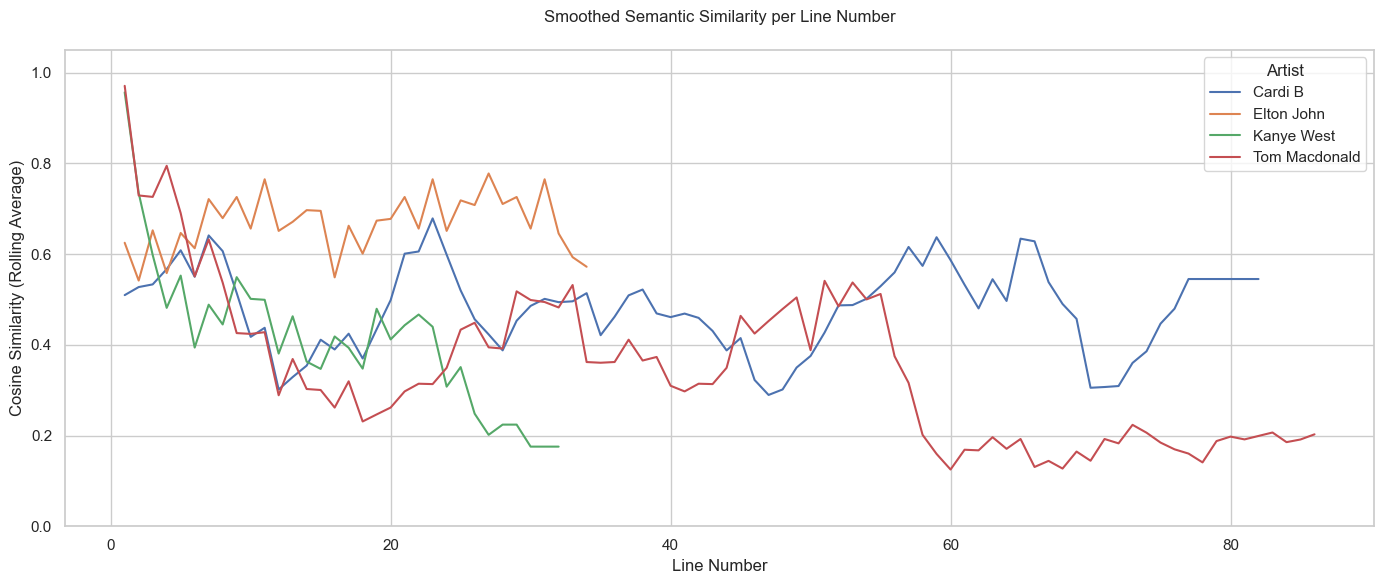

In [81]:
window = 5  # average over 5 lines
plt.figure(figsize=(14,6))

for artist in artists:
    artist_df = df_pivot[df_pivot['artist'] == artist].sort_values('line_number')
    rolling_sim = artist_df['semantic_similarity'].rolling(window=window, min_periods=1).mean()
    plt.plot(
        artist_df['line_number'],
        rolling_sim,
        label=artist
    )

plt.title("Smoothed Semantic Similarity per Line Number")
plt.xlabel("Line Number")
plt.ylabel("Cosine Similarity (Rolling Average)")
plt.ylim(0,1.05)
plt.legend(title="Artist")
plt.grid(True)
plt.tight_layout()
plt.show()


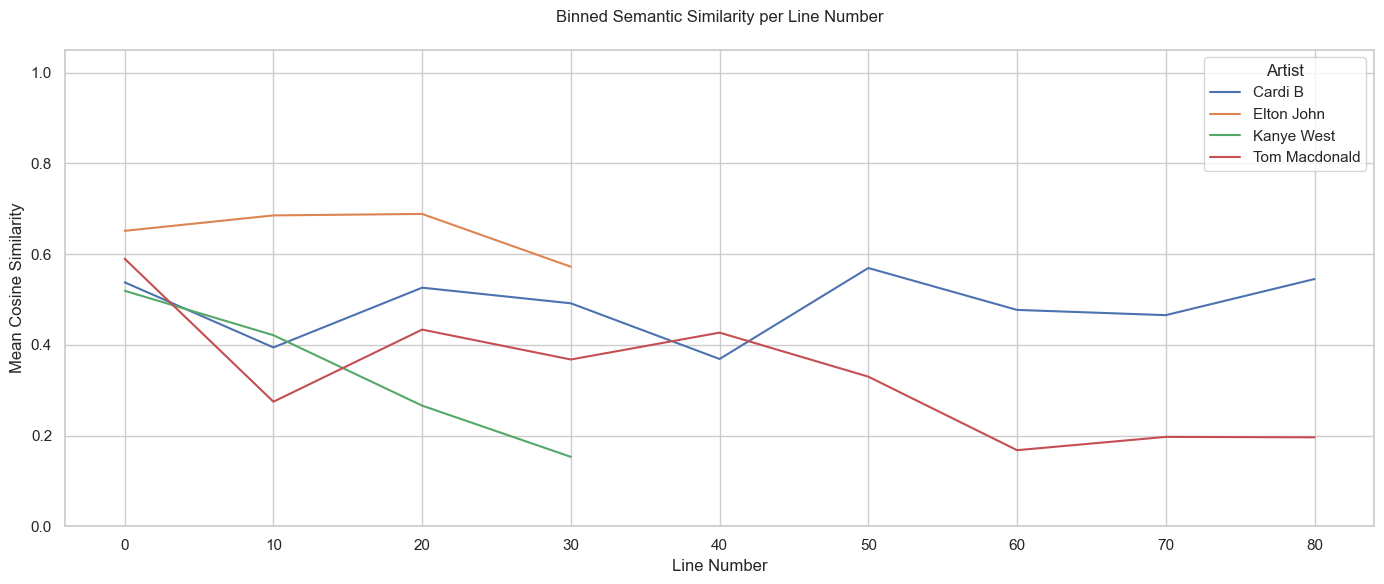

In [80]:
bin_size = 10

plt.figure(figsize=(14,6))

for artist in artists:
    artist_df = df_pivot[df_pivot['artist'] == artist].sort_values('line_number')
    binned = artist_df.groupby(artist_df['line_number'] // bin_size).semantic_similarity.mean()
    plt.plot(
        binned.index * bin_size,
        binned.values,
        label=artist
    )

plt.title("Binned Semantic Similarity per Line Number")
plt.xlabel("Line Number")
plt.ylabel("Mean Cosine Similarity")
plt.ylim(0,1.05)
plt.legend(title="Artist")
plt.grid(True)
plt.tight_layout()
plt.show()
